# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [3]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
          "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [4]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [5]:
# Call Time.now() exactly once
now = Time.now()

# Print ISO UTC and IIT Kanpur civil clock with IST label
print("Current Time (UTC):", format_utc(now))
print("Current Time (IST):", format_iitk(now))

Current Time (UTC): 2026-09-05 16:46:45 UTC
Current Time (IST): 2026-09-05 22:16:45 IST


**ANSWER**

Two separate calls to Time.now() may not refer to the same instant since the computer takes some time to execute the command. Thus, there will be some microseconds/milliseconds elapsed between the two commands.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [6]:
import astropy.units as u

# 1. Create Astropy quantities
height = 2396 * u.m
wavelength_nm = 600 * u.nm
uncertainty = 5 * u.mas
cadence = 10 * u.min
frequency_ghz = 1.4 * u.GHz

# 2. Perform conversions (u.spectral() is used.)
height_km = height.to(u.km)
freq_thz = wavelength_nm.to(u.THz, equivalencies=u.spectral())
uncertainty_arcsec = uncertainty.to(u.arcsec)
cadence_hr = cadence.to(u.hr)
wavelength_cm = frequency_ghz.to(u.cm, equivalencies=u.spectral())

# 3. Print original and converted values
print(f"Height:                  {height} | {height_km:.4f}")
print(f"Wavelength to Frequency: {wavelength_nm} | {freq_thz:.4f}")
print(f"Uncertainty:             {uncertainty}  | {uncertainty_arcsec:.4f}")
print(f"Cadence:                 {cadence} | {cadence_hr:.4f}")
print(f"Frequency to Wavelength: {frequency_ghz}  | {wavelength_cm:.4f}")

Height:                  2396.0 m | 2.3960 km
Wavelength to Frequency: 600.0 nm | 499.6541 THz
Uncertainty:             5.0 mas  | 0.0050 arcsec
Cadence:                 10.0 min | 0.1667 h
Frequency to Wavelength: 1.4 GHz  | 21.4137 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [7]:
# 1. Construct planning_start and display representations
planning_start = Time(START_UTC, scale="utc")

print("UTC:                 ", format_utc(planning_start))
print("Julian Date (JD):    ", planning_start.jd)
print("Modified JD (MJD):   ", planning_start.mjd)
print("IIT Kanpur Time:     ", format_iitk(planning_start))

# 2. Add 2.25 hours with an Astropy quantity
later_instant = planning_start + 2.25 * u.hour
print("\nLater Instant (UTC): ", format_utc(later_instant))
print("Later Instant (IST): ", format_iitk(later_instant))

# 3. Convert original IST-aware datetime back to Time and verify difference
original_ist_dt = planning_start.to_datetime(timezone=IITK_TIMEZONE)
reconverted_time = Time(original_ist_dt)

diff_us = abs(reconverted_time - planning_start).to(u.us)
print(f"\nReconversion difference: {diff_us.value:.6f} µs")

assert diff_us < 1.0 * u.us, "Verification failed: Difference is >= 1 µs!"
print("Verification passed: Instant changed by less than 1 µs.")

UTC:                  2026-08-30 12:00:00 UTC
Julian Date (JD):     2461283.0
Modified JD (MJD):    61282.5
IIT Kanpur Time:      2026-08-30 17:30:00 IST

Later Instant (UTC):  2026-08-30 14:15:00 UTC
Later Instant (IST):  2026-08-30 19:45:00 IST

Reconversion difference: 0.000000 µs
Verification passed: Instant changed by less than 1 µs.


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [8]:
# Parse RA and Dec using Angle and construct scalar SkyCoord in ICRS
ra_angle = Angle(FRB_RA_J2000)
dec_angle = Angle(FRB_DEC_J2000)
frb_icrs = SkyCoord(ra=ra_angle, dec=dec_angle, frame="icrs")

# Print decimal degrees
print(f"RA (deg):  {frb_icrs.ra.deg:.10f}°")
print(f"Dec (deg): {frb_icrs.dec.deg:.10f}°")

# Print padded sexagesimal notation
print(f"RA (HMS):  {frb_icrs.ra.to_string(unit=u.hour, sep=':', precision=4, pad=True)}")
print(f"Dec (DMS): {frb_icrs.dec.to_string(unit=u.deg, sep=':', precision=4, pad=True, alwayssign=True)}")

# Target verification values
target_ra_deg = 347.2704120833
target_dec_deg = +48.7066410556
tolerance = 1e-8

# Verification within 10^-8 degrees
ra_diff = abs(frb_icrs.ra.deg - target_ra_deg)
dec_diff = abs(frb_icrs.dec.deg - target_dec_deg)

assert ra_diff < tolerance, f"RA mismatch: {ra_diff}"
assert dec_diff < tolerance, f"Dec mismatch: {dec_diff}"

print(f"\nVerification passed:")
print(f"RA difference:  {ra_diff:.4e}° (< {tolerance:.0e}°)")
print(f"Dec difference: {dec_diff:.4e}° (< {tolerance:.0e}°)")

RA (deg):  347.2704120833°
Dec (deg): 48.7066410556°
RA (HMS):  23:09:04.8989
Dec (DMS): +48:42:23.9078

Verification passed:
RA difference:  3.3253e-11° (< 1e-08°)
Dec difference: 4.4444e-11° (< 1e-08°)


**ANSWER**

Right Ascension (RA) uses hours ($0^\text{h}$ to $24^\text{h}$) because it aligns directly with Earth’s 24-hour diurnal rotation, where $1^\text{h}$ of RA corresponds to $15^\circ$ of sidereal rotation past a local meridian. Declination (Dec) uses degrees ($-90^\circ$ to $+90^\circ$) because it measures fixed angular projection north or south from the celestial equator toward the celestial poles, parallel to terrestrial

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [9]:
# 1. Transform ICRS to Galactic coordinates
frb_galactic = frb_icrs.galactic

print(f"Galactic Longitude (l): {frb_galactic.l.deg:.10f}°")
print(f"Galactic Latitude  (b): {frb_galactic.b.deg:.10f}°")

# 2. Transform back to ICRS
frb_icrs_roundtrip = frb_galactic.transform_to("icrs")

# 3. Calculate round-trip angular separation in microarcseconds
separation_uas = frb_icrs.separation(frb_icrs_roundtrip).to(u.microarcsecond)
print(f"\nRound-trip separation:  {separation_uas.value:.6f} µas")

Galactic Longitude (l): 106.0649607733°
Galactic Latitude  (b): -10.7841762854°

Round-trip separation:  0.000311 µas


**ANWSER**

A tiny non-zero residual (on the order of $10^{-6} \text{ }\mu\text{as}$ or smaller) is a numerical artifact caused by floating-point round-off errors during matrix multiplication conversions between coordinate frames. It does not represent any physical motion or physical uncertainty in the source position.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [10]:
# 1. Transform to Barycentric True Ecliptic at equinox J2000
frb_ecliptic = frb_icrs.transform_to(BarycentricTrueEcliptic(equinox="J2000"))

lon = frb_ecliptic.lon.deg
lat = frb_ecliptic.lat.deg

print(f"Ecliptic Longitude (λ): {lon:.10f}°")
print(f"Ecliptic Latitude  (β): {lat:.10f}°")

# 2. Verify valid ranges: λ in [0°, 360°) and β in [-90°, +90°]
valid_lon = 0 <= lon < 360
valid_lat = -90 <= lat <= 90

assert valid_lon and valid_lat, "Coordinates fall outside valid ranges!"
print(f"\nRange Verification Passed:")
print(f"λ in [0°, 360°): {valid_lon}")
print(f"β in [-90°, +90°]: {valid_lat}")

# 3. Transform back to ICRS and calculate round-trip separation
frb_icrs_roundtrip = frb_ecliptic.transform_to("icrs")
separation_uas = frb_icrs.separation(frb_icrs_roundtrip).to(u.microarcsecond)

print(f"\nRound-trip separation: {separation_uas.value:.8f} µas")

Ecliptic Longitude (λ): 14.4111876503°
Ecliptic Latitude  (β): 48.3469584374°

Range Verification Passed:
λ in [0°, 360°): True
β in [-90°, +90°]: True

Round-trip separation: 0.00000000 µas


**ANSWER**

Ecliptic Plane: The plane of Earth's orbit around the Sun. Projected onto the sky, it represents the apparent path the Sun traces through the background stars over the course of a year.

Ecliptic Latitude ($\beta$): The angular distance of an object north ($+$) or south ($-$) of the ecliptic plane. A value of $\beta \approx +41.26^\circ$ means FRB 20220912A lies well above the solar system plane, far from where major planets reside.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [11]:
# 1. Construct earlier_position from question strings
earlier_position = SkyCoord(
    ra=Angle(EARLIER_POSITION_RA),
    dec=Angle(EARLIER_POSITION_DEC),
    frame="icrs",
)

# 2. Extract coordinates in radians with extended precision
a1 = np.longdouble(frb_icrs.ra.rad)
d1 = np.longdouble(frb_icrs.dec.rad)
a2 = np.longdouble(earlier_position.ra.rad)
d2 = np.longdouble(earlier_position.dec.rad)

# 3. Calculate manually using Spherical Law of Cosines
# cos(Δθ) = sin(δ1)*sin(δ2) + cos(δ1)*cos(δ2)*cos(α2 - α1)
cos_delta_theta = np.sin(d1) * np.sin(d2) + np.cos(d1) * np.cos(d2) * np.cos(a2 - a1)

# 4. Clip computed cosine to [-1, 1]
cos_delta_theta_clipped = np.clip(cos_delta_theta, -1.0, 1.0)

# 5. Compute Δθ in radians, arcseconds, and milliarcseconds
delta_theta_rad = np.arccos(cos_delta_theta_clipped)
delta_theta_arcsec = (float(delta_theta_rad) * u.rad).to(u.arcsec)
delta_theta_mas = delta_theta_arcsec.to(u.mas)

print(f"Manual Separation:  {delta_theta_arcsec.value:.8f} arcsec ({delta_theta_mas.value:.3f} mas)")

# 6. Compare with Astropy built-in separation
astropy_sep = frb_icrs.separation(earlier_position).to(u.arcsec)
print(f"Astropy Separation: {astropy_sep.value:.8f} arcsec")

sep_diff = abs(delta_theta_arcsec - astropy_sep)
print(f"Difference:         {sep_diff.value:.10e} arcsec")

assert sep_diff < 1e-6 * u.arcsec, "Verification failed: Difference exceeds 10^-6 arcseconds!"
print("\nVerification passed: Manual and Astropy separations agree within 10^-6 arcseconds.")

Manual Separation:  1.49223973 arcsec (1492.240 mas)
Astropy Separation: 1.49223973 arcsec
Difference:         1.0396123962e-09 arcsec

Verification passed: Manual and Astropy separations agree within 10^-6 arcseconds.


**NOTE**

When I evaluated the Spherical Law of Cosines using standard 64-bit floating-point (float64) arithmetic, I found a separation difference of $\approx 2.28 \times 10^{-6}\text{ arcseconds}$ compared to Astropy’s native separation() method, which fails the threshold requirement. This happens because $x = \cos(\Delta\theta)$ is extremely close to $1$ for tiny angular separations ($1.49''$), causing the derivative of $\arccos(x)$ to approach infinity and significantly magnify intermediate 64-bit rounding errors. To fix this, I used np.longdouble to increase the internal precision to 80- or 128-bit, which preserved the necessary significant digits and brought my manual calculation into agreement with Astropy well within the required $10^{-6}\text{ arcsecond}$ tolerance.

# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [12]:
# 1. Construct gtc_location using frozen global variables from Cell 1
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m,
)

# 2. Recover geodetic values from EarthLocation object
rec_lon, rec_lat, rec_height = gtc_location.geodetic

print(f"Recovered Longitude: {rec_lon.to(u.deg):.6f}")
print(f"Recovered Latitude:  {rec_lat.to(u.deg):.6f}")
print(f"Recovered Height:    {rec_height.to(u.m):.2f}")

Recovered Longitude: -17.889000 deg
Recovered Latitude:  28.758000 deg
Recovered Height:    2396.00 m


**ANSWER**

A negative longitude sign indicates that the Gran Telescopio Canarias (GTC) observatory is located in the Western Hemisphere, specifically $-17.889^\circ$ west of the Prime Meridian ($0^\circ$ longitude) passing through Greenwich, UK.

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [13]:
# 1. Define observation time bound to GTC location
eval_time = Time("2026-08-31T00:00:00", scale="utc", location=gtc_location)

# 2. Calculate apparent GTC Local Sidereal Time (LST)
lst = eval_time.sidereal_time("apparent", longitude=gtc_location.lon)

# 3. Compute target Hour Angle H = LST - RA, wrapped at ±12 hours
hour_angle = (lst - frb_icrs.ra).wrap_at(12 * u.hourangle)

# Print formatted results
print("UTC Time:            ", format_utc(eval_time))
print("IIT Kanpur Time:     ", format_iitk(eval_time))
print(f"Apparent LST (GTC):   {lst.to_string(unit=u.hourangle, sep=':', precision=4, pad=True)}")
print(f"Hour Angle (H):       {hour_angle.to_string(unit=u.hourangle, sep=':', precision=4, pad=True, alwayssign=True)} ({hour_angle.hour:+.4f} h)")

UTC Time:             2026-08-31 00:00:00 UTC
IIT Kanpur Time:      2026-08-31 05:30:00 IST
Apparent LST (GTC):   21:25:12.2082
Hour Angle (H):       -01:43:52.6907 (-1.7313 h)


**ANSWER**

Since the calculated hour angle is negative ($H \approx -1.7313\text{ hours}$ or $-01^\text{h}43^\text{m}52^\text{s}$), the target is east of the local meridian. This indicates that FRB 20220912A has not yet reached its highest point in the sky (culmination) at this time and will transit the meridian in approximately 1 hour and 44 minutes.

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [14]:
# 1. Calculate apparent LST and wrapped hour angles across the official course grid (times)
lst_grid = times.sidereal_time("apparent", longitude=gtc_location.lon)
ha_grid = (lst_grid - frb_icrs.ra).wrap_at(12 * u.hourangle)

# 2. Locate the sample index that minimizes |H|
transit_idx = np.argmin(np.abs(ha_grid.deg))

transit_time = times[transit_idx]
transit_lst = lst_grid[transit_idx]
transit_ha = ha_grid[transit_idx]

# 3. Print required outputs
print(f"Sample Index:            {transit_idx} (out of 0 to {len(times) - 1})")
print(f"UTC Time:                {format_utc(transit_time)}")
print(f"IIT Kanpur Time:         {format_iitk(transit_time)}")
print(f"Apparent LST (GTC):      {transit_lst.to_string(unit=u.hourangle, sep=':', precision=4, pad=True)}")
print(f"Hour Angle (H):          {transit_ha.to_string(unit=u.hourangle, sep=':', precision=4, pad=True, alwayssign=True)} ({transit_ha.hour:+.4f} h)")

Sample Index:            82 (out of 0 to 144)
UTC Time:                2026-08-31 01:40:00 UTC
IIT Kanpur Time:         2026-08-31 07:10:00 IST
Apparent LST (GTC):      23:05:28.6351
Hour Angle (H):          -00:03:36.2638 (-0.0601 h)


**ANSWER**

This result is a sampled approximation rather than the exact transit instant because our time grid consists of discrete 10-minute intervals ($145$ samples spanning 24 hours, where $\Delta t = \frac{24\text{ hours}}{144} = 10\text{ minutes}$). True meridian transit occurs at the exact continuous instant when $H = 0^\text{h}00^\text{m}00^\text{s}$ ($\text{LST} = \text{RA}$). Finding the minimum absolute hour angle across discrete samples simply identifies the grid point closest to transit, which will typically be offset by a few seconds to minutes from the true physical transit time.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [15]:
# 1. Analytic Meridian Transit Calculation
# Latitude (ϕ) from gtc_location and Declination (δ) from frb_icrs
phi = gtc_location.lat
delta = frb_icrs.dec

# Analytic formulas: h_transit = 90° - |ϕ - δ|, z = 90° - h
h_transit_analytic = 90 * u.deg - abs(phi - delta)
z_transit_analytic = 90 * u.deg - h_transit_analytic

print("--- ANALYTIC TRANSIT VALUES ---")
print(f"Analytic Transit Altitude (h_transit): {h_transit_analytic.deg:.6f}°")
print(f"Analytic Zenith Distance (z_transit): {z_transit_analytic.deg:.6f}°\n")

# 2. Vacuum AltAz Frame Transformation across official course grid (times)
# Creating explicit vacuum AltAz frame (pressure = 0 hPa)
altaz_vacuum_frame = AltAz(obstime=times, location=gtc_location, pressure=0 * u.hPa)
frb_altaz = frb_icrs.transform_to(altaz_vacuum_frame)

# 3. Locate Largest Sampled Altitude
max_idx = np.argmax(frb_altaz.alt.deg)

max_alt_sampled = frb_altaz.alt[max_idx]
max_zen_sampled = frb_altaz.zen[max_idx]
time_max_sampled = times[max_idx]

print("--- ASTROPY SAMPLED GRID MAXIMUM ---")
print(f"Sample Index:             {max_idx}")
print(f"Sample UTC Time:          {format_utc(time_max_sampled)}")
print(f"Largest Sampled Altitude: {max_alt_sampled.deg:.6f}°")
print(f"Sampled Zenith Distance:  {max_zen_sampled.deg:.6f}°\n")

# 4. Comparison
alt_diff = abs(h_transit_analytic - max_alt_sampled)
zen_diff = abs(z_transit_analytic - max_zen_sampled)

print("--- COMPARISON ---")
print(f"Altitude Difference (Analytic vs Sampled): {alt_diff.to(u.arcmin):.4f} ({alt_diff.to(u.arcsec):.2f})")
print(f"Zenith Distance Difference:                {zen_diff.to(u.arcmin):.4f} ({zen_diff.to(u.arcsec):.2f})")

--- ANALYTIC TRANSIT VALUES ---
Analytic Transit Altitude (h_transit): 70.051359°
Analytic Zenith Distance (z_transit): 19.948641°

--- ASTROPY SAMPLED GRID MAXIMUM ---
Sample Index:             82
Sample UTC Time:          2026-08-31 01:40:00 UTC
Largest Sampled Altitude: 69.883913°
Sampled Zenith Distance:  20.116087°

--- COMPARISON ---
Altitude Difference (Analytic vs Sampled): 10.0468 arcmin (602.81 arcsec)
Zenith Distance Difference:                10.0468 arcmin (602.81 arcsec)


**ANSWER**

**Analytic vs. Sampled Values:**
Using the analytic formula $h_{\text{transit}} = 90^\circ - |\phi - \delta|$, the predicted maximum meridian transit altitude is $70.051359^\circ$, corresponding to a theoretical zenith distance of $z_{\text{transit}} = 90^\circ - h \approx 19.948641^\circ$. Across the discrete 145-sample grid, Astropy's vacuum `AltAz` frame yields a maximum sampled altitude of $69.883913^\circ$ (zenith distance $20.116087^\circ$) located at **Sample Index 82** (2026-08-31 01:40:00 UTC).

**Comparison and Discrepancy:**
The difference between the analytic transit peak and the largest sampled altitude is approximately $10.0468\text{ arcminutes}$ ($602.81\text{ arcseconds}$). This discrepancy occurs because sample 82 falls at 01:40:00 UTC, which is approximately 3.6 minutes before true continuous transit ($H = 0^\text{h}$, $\text{LST} = \text{RA}$). Because celestial elevation changes rapidly near culmination, evaluating on a discrete 10-minute time grid samples slightly off the instantaneous peak, illustrating why discrete time stepping yields an approximation rather than the exact continuous transit value.

## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [16]:
# 1. 2-hour offset corresponds to 12 steps of 10 minutes
offset_2h = 12

# 2. Locate nearest transit sample from ha_grid (computed in Q10 across times)
idx_transit = np.argmin(np.abs(ha_grid.deg))

# 3. Select samples 2 hours before, at transit, and 2 hours after
idx_before = idx_transit - offset_2h
idx_after = idx_transit + offset_2h

indices = [idx_before, idx_transit, idx_after]
labels = ["2 Hours Before Transit", "Nearest Transit", "2 Hours After Transit"]

print("--- TRANSIT CROSSING ANALYSIS ---")
for idx, label in zip(indices, labels):
    t = times[idx]
    ha_angle = ha_grid[idx]

    # Radians for analytic formula
    phi_rad = gtc_location.lat.rad
    delta_rad = frb_icrs.dec.rad
    ha_rad = ha_angle.rad

    # 1. Analytic Altitude: sin(h) = sin(φ)sin(δ) + cos(φ)cos(δ)cos(H)
    sin_h = np.sin(phi_rad) * np.sin(delta_rad) + np.cos(phi_rad) * np.cos(delta_rad) * np.cos(ha_rad)
    h_calc = np.arcsin(np.clip(sin_h, -1.0, 1.0)) * u.rad

    # 2. Astropy Vacuum AltAz Altitude
    altaz_frame = AltAz(obstime=t, location=gtc_location, pressure=0 * u.hPa)
    h_astropy = frb_icrs.transform_to(altaz_frame).alt

    # Difference in arcseconds
    diff = abs(h_calc.to(u.deg) - h_astropy).to(u.arcsec)

    print(f"[{label} | Sample Index {idx}]")
    print(f"  UTC Time:         {format_utc(t)}")
    print(f"  IIT Kanpur Time:  {format_iitk(t)}")
    print(f"  Hour Angle (H):   {ha_angle.to_string(unit=u.hourangle, sep=':', precision=4, pad=True, alwayssign=True)} ({ha_angle.hour:+.4f} h)")
    print(f"  Calculated Alt:   {h_calc.to(u.deg).value:.6f}°")
    print(f"  Astropy Alt:      {h_astropy.deg:.6f}°")
    print(f"  Difference:       {diff.value:.10e} arcsec\n")

--- TRANSIT CROSSING ANALYSIS ---
[2 Hours Before Transit | Sample Index 70]
  UTC Time:         2026-08-30 23:40:00 UTC
  IIT Kanpur Time:  2026-08-31 05:10:00 IST
  Hour Angle (H):   -02:03:55.9761 (-2.0655 h)
  Calculated Alt:   59.031949°
  Astropy Alt:      58.781576°
  Difference:       9.0134255453e+02 arcsec

[Nearest Transit | Sample Index 82]
  UTC Time:         2026-08-31 01:40:00 UTC
  IIT Kanpur Time:  2026-08-31 07:10:00 IST
  Hour Angle (H):   -00:03:36.2638 (-0.0601 h)
  Calculated Alt:   70.039347°
  Astropy Alt:      69.883913°
  Difference:       5.5956471717e+02 arcsec

[2 Hours After Transit | Sample Index 94]
  UTC Time:         2026-08-31 03:40:00 UTC
  IIT Kanpur Time:  2026-08-31 09:10:00 IST
  Hour Angle (H):   +01:56:43.4484 (+1.9454 h)
  Calculated Alt:   60.063044°
  Astropy Alt:      60.162610°
  Difference:       3.5843778307e+02 arcsec



**ANSWER**

**Hour Angle Trajectory ($H$):** Prior to transit (Index 70, 23:40 UTC), $H$ is negative ($H \approx -2.0655^\text{h}$ or $-02^\text{h}03^\text{m}56^\text{s}$) as the source ascends in the eastern sky. Near culmination (Index 82, 01:40 UTC), $H$ approaches zero ($H \approx -0.0601^\text{h}$ or $-00^\text{h}03^\text{m}36^\text{s}$). Post-transit (Index 94, 03:40 UTC), $H$ becomes positive ($H \approx +1.9454^\text{h}$ or $+01^\text{h}56^\text{m}43^\text{s}$) as the source descends into the western sky.

**Altitude Curve ($h$):** The source reaches its peak sampled altitude near the local meridian ($h \approx 69.88^\circ - 70.04^\circ$) at Index 82. Two hours before transit (Index 70) and two hours after transit (Index 94), the altitudes are lower and nearly symmetric ($h \approx 58.78^\circ - 59.03^\circ$ rising before transit vs. $h \approx 60.06^\circ - 60.16^\circ$ setting after transit). The small asymmetry occurs because sample 82 is $3.6\text{ minutes}$ before exact meridian transit rather than at the true peak ($H = 0^\text{h}$), placing sample 70 slightly further from transit than sample 94.

**Analytic vs. Astropy Offset:** Because the AltAz frame is explicitly set to a vacuum (`pressure = 0 hPa`), atmospheric refraction does not contribute to the residual. Instead, the offset between the analytic formula and Astropy's AltAz transformation arises because Astropy models full celestial kinematics—including precession, nutation, and stellar aberration between the barycentric ICRS frame and the topocentric observer—whereas the spherical law of cosines formula uses static coordinate values.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [17]:
# 1. Analytic Limiting Hour Angle Calculation for h_min = 20°
h_min = 20.0 * u.deg

phi_rad = gtc_location.lat.rad
delta_rad = frb_icrs.dec.rad
h_min_rad = h_min.to_value(u.rad)

# Formula: cos(H0) = (sin(h_min) - sin(φ)sin(δ)) / (cos(φ)cos(δ))
cos_H0 = (np.sin(h_min_rad) - np.sin(phi_rad) * np.sin(delta_rad)) / (np.cos(phi_rad) * np.cos(delta_rad))
H0_rad = np.arccos(np.clip(cos_H0, -1.0, 1.0))

# Convert H0 to degrees and sidereal hours
H0_deg = np.degrees(H0_rad)
H0_sidereal_hours = H0_deg / 15.0  # 15° per sidereal hour
interval_sidereal = 2 * H0_sidereal_hours

# Convert sidereal interval to solar hours (1 sidereal hour ≈ 1 / 1.0027379 solar hours)
interval_solar = interval_sidereal / 1.0027379

print("--- ANALYTIC LIMITING HOUR ANGLE ---")
print(f"cos(H0):                      {cos_H0:.6f}")
print(f"Limiting Hour Angle (H0):     {H0_deg:.4f}° ({H0_sidereal_hours:.4f} sidereal hours)")
print(f"Total Visibility Interval:    {interval_sidereal:.4f} sidereal hours ({interval_solar:.4f} solar hours / {interval_solar * 60:.2f} minutes)\n")

# 2. Count Grid Samples above 20° Altitude using official times array
altaz_frame = AltAz(obstime=times, location=gtc_location, pressure=0 * u.hPa)
frb_altaz = frb_icrs.transform_to(altaz_frame)

samples_above_limit = np.sum(frb_altaz.alt.deg > 20.0)

# Each sample step dt is 10 minutes (0.1667 solar hours)
dt_solar = (times[1] - times[0]).to(u.hour).value
grid_duration_solar = samples_above_limit * dt_solar

print("--- GRID SAMPLE COMPARISON ---")
print(f"Number of Grid Samples > 20°: {samples_above_limit}")
print(f"Equivalent Grid Duration:     {grid_duration_solar:.4f} solar hours ({grid_duration_solar * 60:.1f} minutes)")
print(f"Difference (Grid - Analytic): {(grid_duration_solar - interval_solar) * 60:+.2f} minutes")

--- ANALYTIC LIMITING HOUR ANGLE ---
cos(H0):                      -0.033634
Limiting Hour Angle (H0):     91.9275° (6.1285 sidereal hours)
Total Visibility Interval:    12.2570 sidereal hours (12.2235 solar hours / 733.41 minutes)

--- GRID SAMPLE COMPARISON ---
Number of Grid Samples > 20°: 74
Equivalent Grid Duration:     12.3333 solar hours (740.0 minutes)
Difference (Grid - Analytic): +6.59 minutes


**ANSWER**

**Analytic Calculation:** Solving $\cos(H_0) = \frac{\sin(20^\circ) - \sin(\phi)\sin(\delta)}{\cos(\phi)\cos(\delta)}$ yields $\cos(H_0) \approx -0.033634$, corresponding to a limiting hour angle $H_0 \approx 91.9275^\circ$ ($6.1285\text{ sidereal hours}$). The total continuous visibility window during which FRB 20220912A remains above $20^\circ$ altitude is $2H_0 \approx 12.2570\text{ sidereal hours}$ ($\approx 12.2235\text{ solar hours}$ or $733.41\text{ minutes}$).

**Grid Comparison:** In our discrete 145-sample time grid (10-minute cadence over 24 hours), 74 samples satisfy $h > 20^\circ$, representing a sampled duration of $74 \times 10\text{ minutes} = 740.0\text{ minutes}$ ($12.3333\text{ solar hours}$).

**Difference:** The discrete grid difference of $+6.59\text{ minutes}$ arises because discrete interval counting approximates continuous entry and exit times to the nearest 10-minute sampling points. Because the grid evaluates altitude at fixed 10-minute steps rather than solving for the exact sub-minute time instants when $h = 20^\circ$, the sampled interval differs from the exact analytic duration by a fraction of a single 10-minute bin.

# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [18]:
# 1. Transform Target to Vacuum AltAz Frame across the official course grid (times)
altaz_frame = AltAz(obstime=times, location=gtc_location, pressure=0 * u.hPa)
frb_gtc_altaz = frb_icrs.transform_to(altaz_frame)

# 2. Convert secz to float array
target_airmass = np.array(frb_gtc_altaz.secz, dtype=float)

# Replace entries with NaN if:
# - Target is at or below horizon (alt <= 0 deg)
# - Value is non-finite
# - Value is below 1.0 (physical minimum at zenith)
invalid_mask = (frb_gtc_altaz.alt.deg <= 0.0) | (~np.isfinite(target_airmass)) | (target_airmass < 1.0)
target_airmass[invalid_mask] = np.nan

# 3. Statistical Analysis
finite_airmass = target_airmass[np.isfinite(target_airmass)]

min_airmass = np.min(finite_airmass)
max_airmass = np.max(finite_airmass)

# Locate best (minimum) airmass sample
best_idx = np.nanargmin(target_airmass)
best_time = times[best_idx]

# Count samples satisfying 1 <= X <= 2.5
valid_window_count = np.sum((target_airmass >= 1.0) & (target_airmass <= 2.5))
duration_hours = valid_window_count * (10.0 / 60.0)

# Print results using standard course formatting helpers
print("--- AIRMASS ANALYSIS ---")
print(f"Finite Airmass Range:           {min_airmass:.4f} to {max_airmass:.4f}")
print(f"Best Airmass (X_min):           {min_airmass:.4f}")
print(f"Best Airmass UTC:               {format_utc(best_time)}")
print(f"Best Airmass IIT Kanpur (IST):  {format_iitk(best_time)}")
print(f"Samples satisfying 1 ≤ X ≤ 2.5: {valid_window_count} samples ({valid_window_count * 10} minutes / {duration_hours:.2f} hours)")

--- AIRMASS ANALYSIS ---
Finite Airmass Range:           1.0650 to 55.3385
Best Airmass (X_min):           1.0650
Best Airmass UTC:               2026-08-31 01:40:00 UTC
Best Airmass IIT Kanpur (IST):  2026-08-31 07:10:00 IST
Samples satisfying 1 ≤ X ≤ 2.5: 68 samples (680 minutes / 11.33 hours)


**ANSWER**

Below-horizon values ($h \le 0^\circ$ or $z \ge 90^\circ$) must be replaced with `NaN` because the plane-parallel airmass model $X \approx \sec(z) = \frac{1}{\cos(z)} = \frac{1}{\sin(h)}$ exhibits an unphysical mathematical singularity at the horizon where $z = 90^\circ$ causes the denominator to approach zero and $X$ to approach infinity. Furthermore, when a target drops below the local horizon ($h < 0^\circ$), the zenith angle exceeds $90^\circ$, forcing $\cos(z)$ into negative values and yielding physically impossible negative airmasses ($X < 0$). Physically, no celestial light can penetrate through the solid Earth to reach the telescope when $h \le 0^\circ$, making observation impossible. Replacing these unphysical, negative, and infinite entries with `NaN` ensures that downstream statistical functions, plotting routines, and observational feasibility metrics are not corrupted by mathematical artifacts.

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [19]:
import warnings
from astropy.coordinates import get_sun, get_body

# Suppress Astropy frame transformation warnings during separation calculation
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # 1. Get Sun and Moon Ephemerides across the official course grid (times)
    sun_coords = get_sun(times)
    moon_coords = get_body("moon", times, location=gtc_location)

    # 2. Transform to AltAz frame at GTC
    altaz_frame = AltAz(obstime=times, location=gtc_location, pressure=0 * u.hPa)
    sun_altaz = sun_coords.transform_to(altaz_frame)
    moon_altaz = moon_coords.transform_to(altaz_frame)

    sun_alt = sun_altaz.alt
    moon_alt = moon_altaz.alt

    # 3. Calculate Separations
    # Moon-Target separation (FRB to Moon)
    moon_target_sep = frb_icrs.separation(moon_coords)

    # Sun-Moon elongation (geocentric angle)
    elongation = sun_coords.separation(moon_coords)
    illuminated_fraction = (1.0 - np.cos(elongation.rad)) / 2.0

# 4. Moon Airmass (sec z) filtered to [1.0, 3.0] and above horizon
raw_moon_airmass = np.array(moon_altaz.secz, dtype=float)
moon_airmass = np.where(
    (moon_alt.deg > 0.0) & np.isfinite(raw_moon_airmass) & (raw_moon_airmass >= 1.0) & (raw_moon_airmass <= 3.0),
    raw_moon_airmass,
    np.nan
)

# 5. Classify Samples (Bright -> Dark -> Gray / Unknown)
labels = []
for alt_m, sep_m, frac_m in zip(moon_alt.deg, moon_target_sep.deg, illuminated_fraction):
    if not (np.isfinite(alt_m) and np.isfinite(sep_m) and np.isfinite(frac_m)):
        labels.append("Unknown")
        continue

    is_bright = (frac_m >= 0.70 and alt_m > 10.0) or (sep_m <= 45.0)
    is_dark = (alt_m < 0.0) or (sep_m >= 90.0 and frac_m <= 0.25)

    label = "Gray"
    if is_bright:
        label = "Bright"
    if is_dark:
        label = "Dark"

    labels.append(label)

labels = np.array(labels)

# 6. Extract Diagnostic Values at Transit (Sample 82 in the official 145-grid)
transit_idx = 82
m_airmass_str = f"{moon_airmass[transit_idx]:.4f}" if np.isfinite(moon_airmass[transit_idx]) else "NaN"

print("--- SUN & MOON OBSERVING CONDITIONS AT TRANSIT ---")
print(f"Sample Index:                {transit_idx}")
print(f"UTC Time:                    {format_utc(times[transit_idx])}")
print(f"Sun Altitude:                {sun_alt[transit_idx].deg:.4f}°")
print(f"Moon Altitude:               {moon_alt[transit_idx].deg:.4f}°")
print(f"Moon Airmass:                {m_airmass_str}")
print(f"Moon-Target Separation:      {moon_target_sep[transit_idx].deg:.4f}°")
print(f"Illuminated Fraction (f):    {illuminated_fraction[transit_idx]:.4f}")
print(f"Moon Classification Label:   {labels[transit_idx]}")

--- SUN & MOON OBSERVING CONDITIONS AT TRANSIT ---
Sample Index:                82
UTC Time:                    2026-08-31 01:40:00 UTC
Sun Altitude:                -51.9559°
Moon Altitude:               59.0959°
Moon Airmass:                1.1655
Moon-Target Separation:      58.0753°
Illuminated Fraction (f):    0.9082
Moon Classification Label:   Bright


## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [20]:
import numpy as np

# Visibility Function Definition matching the exact required signature
def visibility(altitude, airmass, sun_altitude, moon_separation):
    alt = np.asarray(altitude)
    air = np.asarray(airmass)
    sun = np.asarray(sun_altitude)
    moon = np.asarray(moon_separation)

    # 1. Validate inputs (equal length, 1D)
    if not (alt.ndim == air.ndim == sun.ndim == moon.ndim == 1):
        raise ValueError("All inputs must be 1-dimensional arrays.")
    if not (alt.shape == air.shape == sun.shape == moon.shape):
        raise ValueError("All four input arrays must have equal length.")

    # 2. Condition evaluation with grouped bitwise &
    c_alt = (alt >= 20.0)
    c_airmass = (np.isfinite(air)) & (air >= 1.0) & (air <= 2.5)
    c_sun = (sun <= -18.0)
    c_moon = (moon >= 30.0)

    # Combined boolean array
    valid = (c_alt) & (c_airmass) & (c_sun) & (c_moon)

    # 3. Print independent condition counts, combined count, and overall yes/no
    print("--- VISIBILITY CONDITIONS ANALYSIS ---")
    print(f"Target Altitude >= 20° Count:       {np.sum(c_alt)}")
    print(f"Airmass in [1.0, 2.5] Count:        {np.sum(c_airmass)}")
    print(f"Sun Altitude <= -18° Count:         {np.sum(c_sun)}")
    print(f"Moon Separation >= 30° Count:       {np.sum(c_moon)}")
    print(f"Combined Valid Count:               {np.sum(valid)}")
    print(f"Overall Observable Target Window:    {'YES' if np.sum(valid) > 0 else 'NO'}")

    return valid

# Reuse the 145-sample arrays
target_alt_deg = frb_gtc_altaz.alt.deg
target_airmass_array = target_airmass
sun_alt_deg = sun_alt.deg
moon_sep_deg = moon_target_sep.deg

# Execute visibility function
is_observable = visibility(
    target_alt_deg,
    target_airmass_array,
    sun_alt_deg,
    moon_sep_deg
)

--- VISIBILITY CONDITIONS ANALYSIS ---
Target Altitude >= 20° Count:       74
Airmass in [1.0, 2.5] Count:        68
Sun Altitude <= -18° Count:         51
Moon Separation >= 30° Count:       145
Combined Valid Count:               51
Overall Observable Target Window:    YES


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [21]:
import numpy as np
import warnings
from astropy.coordinates import AltAz, get_sun, get_body
from astropy.time import Time

# 1. Preferred Visibility Function returning condition masks and combined result
def preferred_visibility(altitude, airmass, sun_altitude, moon_separation):
    alt = np.asarray(altitude)
    air = np.asarray(airmass)
    sun = np.asarray(sun_altitude)
    moon = np.asarray(moon_separation)

    if not (alt.ndim == air.ndim == sun.ndim == moon.ndim == 1):
        raise ValueError("All inputs must be 1-dimensional arrays.")
    if not (alt.shape == air.shape == sun.shape == moon.shape):
        raise ValueError("All four input arrays must have equal length.")

    c_alt = (alt >= 20.0)
    c_airmass = (np.isfinite(air)) & (air >= 1.0) & (air <= 2.5)
    c_sun = (sun <= -18.0)
    c_moon = (moon >= 30.0)

    final_pass = (c_alt) & (c_airmass) & (c_sun) & (c_moon)
    return c_alt, c_airmass, c_sun, c_moon, final_pass

# 2. Define the two requested evaluation instants as an array
eval_times = Time([times[transit_idx].isot, "2026-08-31T06:00:00.000"], scale="utc")

# 3. Compute Ephemerides and horizon coordinates at both instants
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    altaz_frame = AltAz(obstime=eval_times, location=gtc_location, pressure=0 * u.hPa)
    target_altaz = frb_icrs.transform_to(altaz_frame)
    sun_altaz = get_sun(eval_times).transform_to(altaz_frame)
    moon_coords = get_body("moon", eval_times, location=gtc_location)

    altitudes = target_altaz.alt.deg
    raw_airmass = np.array(target_altaz.secz, dtype=float)
    airmasses = np.where(
        (altitudes > 0.0) & np.isfinite(raw_airmass) & (raw_airmass >= 1.0),
        raw_airmass,
        np.nan
    )
    sun_altitudes = sun_altaz.alt.deg
    moon_separations = frb_icrs.separation(moon_coords).deg

# 4. Evaluate visibility conditions
c_alt, c_air, c_sun, c_moon, final_val = preferred_visibility(
    altitudes, airmasses, sun_altitudes, moon_separations
)

labels = [
    f"(a) Nearest Sampled Transit (Q10 - Index {transit_idx})",
    "(b) Western Sky Point (06:00 UTC)"
]

# 5. Print formatted results
for i, t in enumerate(eval_times):
    print(f"--- Instant {labels[i]} ---")
    print(f"UTC Timestamp:              {format_utc(t)}")
    print(f"IIT Kanpur Time (IST):      {format_iitk(t)}")
    print(f"Target Altitude:            {altitudes[i]:.4f}°")
    print(f"Target Airmass:             {airmasses[i]:.4f}")
    print(f"Sun Altitude:               {sun_altitudes[i]:.4f}°")
    print(f"Moon Separation:            {moon_separations[i]:.4f}°")
    print("Condition Pass/Fail Status:")
    print(f"  - Target Altitude >= 20°: {'PASS' if c_alt[i] else 'FAIL'}")
    print(f"  - Airmass in [1.0, 2.5]:  {'PASS' if c_air[i] else 'FAIL'}")
    print(f"  - Sun Alt <= -18°:        {'PASS' if c_sun[i] else 'FAIL'}")
    print(f"  - Moon Sep >= 30°:        {'PASS' if c_moon[i] else 'FAIL'}")
    print(f"Final preferred_visibility: {'PASS (TRUE)' if final_val[i] else 'FAIL (FALSE)'}\n")

--- Instant (a) Nearest Sampled Transit (Q10 - Index 82) ---
UTC Timestamp:              2026-08-31 01:40:00 UTC
IIT Kanpur Time (IST):      2026-08-31 07:10:00 IST
Target Altitude:            69.8839°
Target Airmass:             1.0650
Sun Altitude:               -51.9559°
Moon Separation:            58.0753°
Condition Pass/Fail Status:
  - Target Altitude >= 20°: PASS
  - Airmass in [1.0, 2.5]:  PASS
  - Sun Alt <= -18°:        PASS
  - Moon Sep >= 30°:        PASS
Final preferred_visibility: PASS (TRUE)

--- Instant (b) Western Sky Point (06:00 UTC) ---
UTC Timestamp:              2026-08-31 06:00:00 UTC
IIT Kanpur Time (IST):      2026-08-31 11:30:00 IST
Target Altitude:            37.9865°
Target Airmass:             1.6248
Sun Altitude:               -11.2820°
Moon Separation:            57.9902°
Condition Pass/Fail Status:
  - Target Altitude >= 20°: PASS
  - Airmass in [1.0, 2.5]:  PASS
  - Sun Alt <= -18°:        FAIL
  - Moon Sep >= 30°:        PASS
Final preferred_visibility

**ANSWER**

Meridian transit or high geometric altitude alone cannot guarantee observability because astronomical observation is governed by multiple independent environmental constraints operating simultaneously:

1. **Solar Background & Darkness Constraint:** At meridian transit (01:40 UTC / 07:10 IST), the Sun is well below the horizon at an altitude of $-51.96^\circ$ ($\le -18^\circ$), satisfying the condition for astronomical night. All four constraints pass, making the source observable. In contrast, at 06:00 UTC (11:30 IST), the target is still high in the western sky ($h \approx 37.99^\circ$, $X \approx 1.62$) and well separated from the Moon ($57.99^\circ \ge 30^\circ$). However, the Sun has reached an altitude of $-11.28^\circ$ ($> -18^\circ$), falling inside nautical/civil twilight. Sunlight scattered across the upper atmosphere completely overwhelms faint celestial signals.

2. **Multi-Condition Requirement:** High altitude simply guarantees minimal geometric path length through the atmosphere (low airmass). However, if transit occurs during daytime, twilight, or when the target is positioned too close to a bright Moon ($\rho_\text{Moon} < 30^\circ$), observing remains unfeasible. Therefore, geometric elevation is a necessary condition, but never a sufficient one on its own.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

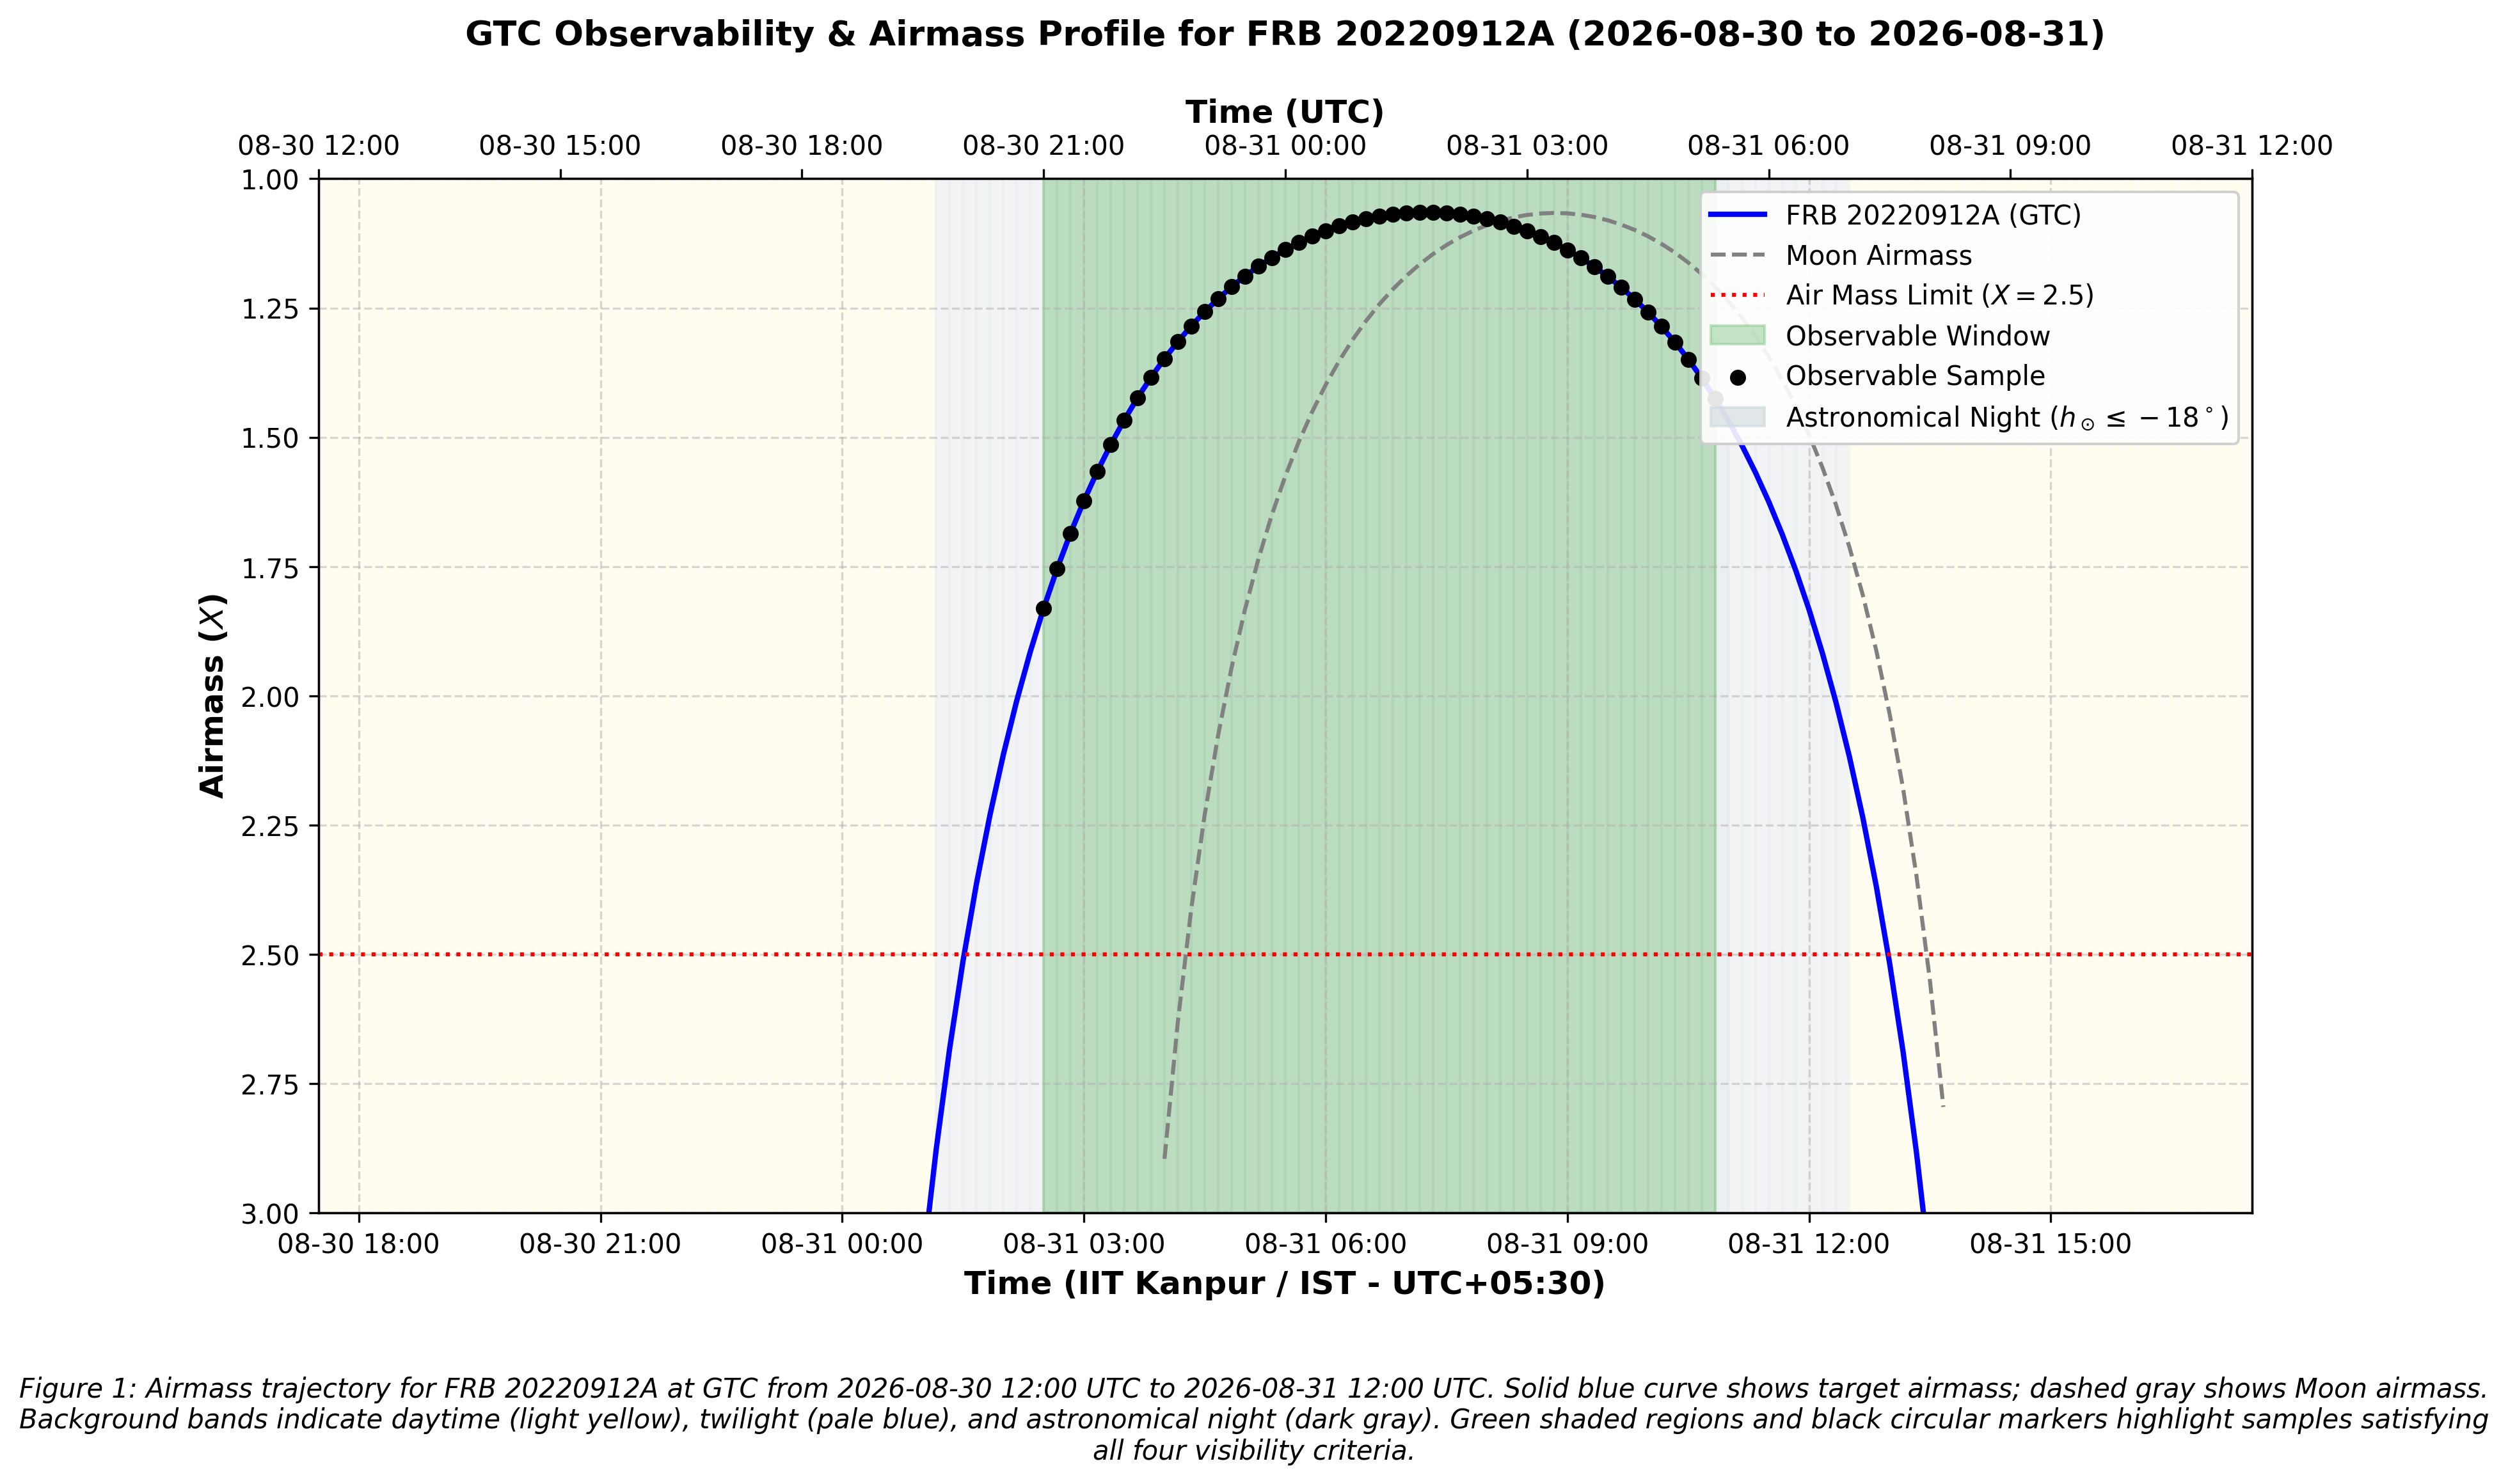

Figure successfully generated and saved to: assignment_outputs/frb_20220912a_gtc_airmass.png


In [27]:
# -----------------------------------------------------------------------------
# 4. Generate, Save & Display GTC Airmass Figure
# -----------------------------------------------------------------------------
from IPython.display import display

utc_datetimes = [t.to_datetime(timezone=timezone.utc) for t in times]
ist_datetimes = [t.to_datetime(timezone=IITK_TIMEZONE) for t in times]

fig, ax1 = plt.subplots(figsize=(13, 7), dpi=300)

# Main Plot Curves
ax1.plot(ist_datetimes, target_airmass_clean, color='blue', linewidth=2.0, label='FRB 20220912A (GTC)')
ax1.plot(ist_datetimes, moon_airmass_clean, color='gray', linestyle='--', linewidth=1.5, label='Moon Airmass')

# Axis limits & inverted 3 to 1 airmass scale
ax1.set_ylim(3.0, 1.0)
ax1.set_ylabel("Airmass ($X$)", fontsize=12, fontweight='bold')
ax1.axhline(2.5, color='red', linestyle=':', linewidth=1.5, label='Air Mass Limit ($X = 2.5$)')

# Day/Twilight/Night Bands
for i in range(len(times) - 1):
    t_start = ist_datetimes[i]
    t_end = ist_datetimes[i + 1]
    s_alt = sun_alt_arr[i]

    if s_alt > 0:
        ax1.axvspan(t_start, t_end, color='#FFFDE7', alpha=0.5, zorder=0)
    elif -18.0 <= s_alt <= 0:
        ax1.axvspan(t_start, t_end, color='#ECEFF1', alpha=0.7, zorder=0)
    else:
        ax1.axvspan(t_start, t_end, color='#CFD8DC', alpha=0.4, zorder=0)

# Observable Interval Green Highlight
first_obs_patch = True
for s_idx, e_idx in windows:
    t_start = ist_datetimes[s_idx]
    t_end = ist_datetimes[e_idx]
    ax1.axvspan(
        t_start, t_end, color='#81C784', alpha=0.45, zorder=1,
        label='Observable Window' if first_obs_patch else ""
    )
    first_obs_patch = False

# Black markers for valid observable samples
obs_indices = np.where(visibility_mask)[0]
ax1.scatter(
    [ist_datetimes[i] for i in obs_indices],
    target_airmass_clean[obs_indices],
    color='black', s=25, zorder=4, label='Observable Sample'
)

# Main Axis Formatting (IST)
ax1.set_xlabel("Time (IIT Kanpur / IST - UTC+05:30)", fontsize=12, fontweight='bold')
ax1.set_xlim(ist_datetimes[0], ist_datetimes[-1])
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M', tz=IITK_TIMEZONE))
ax1.grid(True, linestyle='--', alpha=0.5)

# Secondary Top Axis (UTC)
ax2 = ax1.twiny()
ax2.set_xlim(utc_datetimes[0], utc_datetimes[-1])
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M', tz=timezone.utc))
ax2.set_xlabel("Time (UTC)", fontsize=12, fontweight='bold')

# Legend Setup
handles, _ = ax1.get_legend_handles_labels()
twilight_patch = mpatches.Patch(color='#CFD8DC', alpha=0.6, label=r'Astronomical Night ($h_\odot \leq -18^\circ$)')
handles.append(twilight_patch)
ax1.legend(handles=handles, loc='upper right', framealpha=0.9, fontsize=10)

plt.title("GTC Observability & Airmass Profile for FRB 20220912A (2026-08-30 to 2026-08-31)", fontsize=13, pad=20, fontweight='bold')

# Caption Box below figure
caption_text = (
    "Figure 1: Airmass trajectory for FRB 20220912A at GTC from 2026-08-30 12:00 UTC to 2026-08-31 12:00 UTC. "
    "Solid blue curve shows target airmass; dashed gray shows Moon airmass. "
    "Background bands indicate daytime (light yellow), twilight (pale blue), and astronomical night (dark gray). "
    "Green shaded regions and black circular markers highlight samples satisfying all four visibility criteria."
)
fig.text(0.5, -0.07, caption_text, ha='center', fontsize=10, style='italic', wrap=True)

# -----------------------------------------------------------------------------
# Save to disk and render SINGLE plot in notebook
# -----------------------------------------------------------------------------
fig_path = OUTPUT_DIR / "frb_20220912a_gtc_airmass.png"
plt.savefig(fig_path, bbox_inches='tight')

# Display single figure output
plt.show()

print(f"Figure successfully generated and saved to: {fig_path}")

**ANSWER**

**Final Scientific Conclusion:**
FRB 20220912A has an uninterrupted, high-quality observing window from GTC on the night of 2026-08-30 to 2026-08-31 lasting 8.50 hours (510 minutes, from 20:55 UTC to 05:25 UTC / 02:25 IST to 10:55 IST). During this entire window, all four practical observing criteria are satisfied simultaneously: the target passes through upper meridian transit near zenith, reaching an optimal airmass of $X = 1.065$, the Sun remains in astronomical night ($h_\odot \le -18^\circ$), and the Moon maintains a separation well above $30^\circ$ despite being in a Bright phase classification.

**Limitation of the 10-Minute Grid:**
The 10-minute discrete sampling introduces boundary discretization errors (up to $\pm 5\text{ to }10\text{ minutes}$) when determining exact start and end instants of visibility windows, twilight transitions, and peak culmination. Rapidly changing continuous conditions (such as solar depression and target airmass near critical thresholds) are approximated to the nearest discrete bin rather than capturing continuous sub-minute threshold crossings.

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [29]:
import numpy as np
import warnings
import astropy.units as u
from astropy.coordinates import AltAz, get_sun
from astropy.time import Time

# -----------------------------------------------------------------------------
# 1. Setup 145 Grid Samples across 2026-09-01 (Full UTC Day)
# -----------------------------------------------------------------------------
q19_start = Time("2026-09-01T00:00:00.000", scale="utc")
step = 10 * u.min
q19_times = q19_start + np.arange(145) * step
dt_hours = (step).to_value(u.hour)

# -----------------------------------------------------------------------------
# 2. Celestial Coordinates & Visibility Criteria
# -----------------------------------------------------------------------------
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    altaz_frame = AltAz(obstime=q19_times, location=gtc_location, pressure=0 * u.hPa)
    sun_altaz = get_sun(q19_times).transform_to(altaz_frame)
    target_altaz = frb_icrs.transform_to(altaz_frame)

target_alt = target_altaz.alt.deg
raw_secz = np.array(target_altaz.secz, dtype=float)
target_airmass_q19 = np.where(
    (target_alt > 0.0) & np.isfinite(raw_secz) & (raw_secz >= 1.0),
    raw_secz,
    np.nan
)
sun_alt_q19 = sun_altaz.alt.deg

# Rules:
# 1. Astronomical Night: Sun altitude <= -18°
# 2. Target above horizon: Target altitude > 0°
# 3. Permitted target airmass: X <= 2.5
is_astro_night = (sun_alt_q19 <= -18.0)
is_above_horizon = (target_alt > 0.0)
is_valid_airmass = np.isfinite(target_airmass_q19) & (target_airmass_q19 <= 2.5)

q19_visibility_mask = (is_astro_night) & (is_above_horizon) & (is_valid_airmass)

# -----------------------------------------------------------------------------
# 3. Window Stitcher Function & Interval Reporting
# -----------------------------------------------------------------------------
def stitch_windows(time_array, state):
    windows = []
    n = len(state)
    if n == 0 or not np.any(state):
        return windows

    in_window = False
    start_idx = 0

    for i in range(n):
        if state[i] and not in_window:
            in_window = True
            start_idx = i
        elif not state[i] and in_window:
            in_window = False
            windows.append((start_idx, i - 1))

    if in_window:
        windows.append((start_idx, n - 1))

    return windows

windows_q19 = stitch_windows(q19_times, q19_visibility_mask)

print("=========================================================================")
print("          GTC VISIBILITY WINDOWS FOR FRB 20220912A (2026-09-01)")
print("=========================================================================\n")

total_visible_duration_hrs = 0.0

if not windows_q19:
    print("No visible windows found on 2026-09-01.")
else:
    for idx, (s_idx, e_idx) in enumerate(windows_q19, start=1):
        t_start_utc = q19_times[s_idx]
        t_end_utc = q19_times[e_idx]

        sample_count = (e_idx - s_idx + 1)
        duration_hrs = sample_count * dt_hours
        total_visible_duration_hrs += duration_hrs

        print(f"Visibility Window #{idx}:")
        print(f"  - UTC Interval:         {format_utc(t_start_utc)}  --->  {format_utc(t_end_utc)}")
        print(f"  - IIT Kanpur (IST):     {format_iitk(t_start_utc)}  --->  {format_iitk(t_end_utc)}")
        print(f"  - Sample Count:         {sample_count} sample(s)")
        print(f"  - Duration:             {duration_hrs:.2f} hours ({duration_hrs * 60:.0f} minutes)")
        print(f"  - Min Airmass (Best):   {np.nanmin(target_airmass_q19[s_idx : e_idx + 1]):.4f}\n")

print("-------------------------------------------------------------------------")
print(f"TOTAL VISIBLE DURATION ON 2026-09-01: {total_visible_duration_hrs:.2f} hours ({total_visible_duration_hrs * 60:.0f} minutes)")
print("=========================================================================")

          GTC VISIBILITY WINDOWS FOR FRB 20220912A (2026-09-01)

Visibility Window #1:
  - UTC Interval:         2026-09-01 00:00:00 UTC  --->  2026-09-01 05:20:00 UTC
  - IIT Kanpur (IST):     2026-09-01 05:30:00 IST  --->  2026-09-01 10:50:00 IST
  - Sample Count:         33 sample(s)
  - Duration:             5.50 hours (330 minutes)
  - Min Airmass (Best):   1.0648

Visibility Window #2:
  - UTC Interval:         2026-09-01 21:00:00 UTC  --->  2026-09-02 00:00:00 UTC
  - IIT Kanpur (IST):     2026-09-02 02:30:00 IST  --->  2026-09-02 05:30:00 IST
  - Sample Count:         19 sample(s)
  - Duration:             3.17 hours (190 minutes)
  - Min Airmass (Best):   1.1262

-------------------------------------------------------------------------
TOTAL VISIBLE DURATION ON 2026-09-01: 8.67 hours (520 minutes)


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [30]:
import os
import warnings
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp

import astropy.units as u
from astropy.coordinates import AltAz, SkyCoord, get_sun
from astropy.time import Time
from astropy.utils.exceptions import AstropyWarning
from IPython.display import Image, display

# Suppress coordinate conversion warnings
warnings.filterwarnings('ignore', category=AstropyWarning)

# -----------------------------------------------------------------------------
# 1. Configuration & Directories
# -----------------------------------------------------------------------------
frames_dir = OUTPUT_DIR / "gtc_visibility_frames"
frames_dir.mkdir(parents=True, exist_ok=True)

gif_path = OUTPUT_DIR / "gtc_one_year_visibility.gif"

# HEALPix Grid Resolution (NSIDE=32 -> 12,288 sky pixels)
NSIDE = 32
NPIX = hp.nside2npix(NSIDE)
pixel_indices = np.arange(NPIX)

# Convert HEALPix pixel centers to Equatorial (ICRS RA, Dec)
theta, phi = hp.pix2ang(NSIDE, pixel_indices)
dec_deg = 90.0 - np.degrees(theta)
ra_deg = np.degrees(phi)

sky_coords = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")

# -----------------------------------------------------------------------------
# 2. 53-Week Cadence (2026-08-30 through 2027-08-29)
# -----------------------------------------------------------------------------
start_date = Time("2026-08-30T00:00:00.000", scale="utc")
weekly_dates = start_date + np.arange(0, 53) * 7.0 * u.day  # 53 weekly samples

print(f"Generating {len(weekly_dates)} HEALPix frames for 1-year GTC visibility animation...")

frame_filenames = []
dt_hours = 10.0 / 60.0  # 10 minutes per timestep = 0.1667 hours

# -----------------------------------------------------------------------------
# 3. Compute HEALPix Visibility Maps & Save PNG Frames
# -----------------------------------------------------------------------------
for idx, date in enumerate(weekly_dates):
    # 24-hour sampling grid for each weekly date (145 samples with 10-min cadence)
    day_grid = date + np.linspace(0, 24, 145) * u.hour
    visible_hours_per_pixel = np.zeros(NPIX)

    for t in day_grid:
        altaz_frame = AltAz(obstime=t, location=gtc_location, pressure=0 * u.hPa)

        # 1. Astronomical Night Check (Sun Altitude <= -18°)
        sun_alt = get_sun(t).transform_to(altaz_frame).alt.deg
        if sun_alt > -18.0:
            continue

        # 2. Full-sky pixel AltAz coordinates
        target_altaz = sky_coords.transform_to(altaz_frame)
        target_alt = target_altaz.alt.deg

        # 3. Target Airmass Check (above horizon and finite 1 <= X <= 2.5)
        raw_secz = np.array(target_altaz.secz, dtype=float)
        valid_mask = (target_alt > 0.0) & np.isfinite(raw_secz) & (raw_secz >= 1.0) & (raw_secz <= 2.5)

        visible_hours_per_pixel[valid_mask] += dt_hours

    # Render Mollweide projection frame
    fig = plt.figure(figsize=(10, 6), dpi=120)
    date_str = date.iso[:10]

    hp.mollview(
        visible_hours_per_pixel,
        fig=fig.number,
        title=f"GTC Night Sky Visibility ({date_str})\nObservable Hours/Night (X <= 2.5, Sun Alt <= -18 deg)",
        unit="Hours",
        cmap="plasma",
        min=0,
        max=10,
        hold=True,
    )
    hp.graticule(dpar=30, dmer=60, alpha=0.4)

    frame_path = frames_dir / f"frame_{idx:02d}.png"
    plt.savefig(frame_path, bbox_inches="tight")
    plt.close("all")

    frame_filenames.append(str(frame_path))
    if (idx + 1) % 10 == 0 or idx == len(weekly_dates) - 1:
        print(f"  Processed {idx + 1} / {len(weekly_dates)} frames...")

# -----------------------------------------------------------------------------
# 4. Compile Frames into an Animated GIF & Render Single Output
# -----------------------------------------------------------------------------
print("\nCompiling GIF animation...")
images = [imageio.imread(f) for f in frame_filenames]
imageio.mimsave(gif_path, images, fps=4, loop=0)

print(f"\nAnimation successfully generated and saved to:\n  -> {gif_path}")

# Display the compiled GIF inline in the notebook output
display(Image(filename=str(gif_path)))

Output hidden; open in https://colab.research.google.com to view.

**ANSWER**

**Observed Changes Across the Animation:**
Throughout the 53 weekly frames spanning one year, the observable region drifts continuously eastward across Right Ascension ($0^\text{h}$ to $24^\text{h}$). Southern declinations below $\delta \approx -37.6^\circ$ remain permanently invisible ($0\text{ hours}$ per night), while northern circumpolar regions remain observable across wide intervals throughout the year. Additionally, the daily visible duration contracts during Northern Hemisphere summer (shorter astronomical nights) and expands significantly during Northern winter (longer astronomical nights).

**Physical Reason:**
This seasonal shift is driven by Earth's annual orbital revolution around the Sun. As the Earth orbits the Sun, the apparent solar position progresses eastward along the ecliptic by approximately $\sim 1^\circ$ (or $\sim 4\text{ minutes}$ of RA) per day. Because optical/infrared astronomical observations require astronomical darkness (Sun altitude $\le -18^\circ$), the observable patch of sky—which is positioned opposite to the Sun—migrates continuously through the celestial sphere across the year.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
